In [1]:
#install
!pip install neurokit2
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
print('Preparation complete.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 48.7 MB/s eta 0:00:00
Preparation complete.


In [3]:
DURATION=60
SAMPLING_RATE=500

#physionetのECG使用
ecg_signal, info=nk.ecg_process(nk.ecg_simulate(duration=DURATION, sampling_rate=SAMPLING_RATE))
print("ECG data complete")
print(info)

ECG data complete
{'method_peaks': 'neurokit', 'method_fixpeaks': 'None', 'ECG_R_Peaks': array([  430,   867,  1302,  1728,  2149,  2574,  3002,  3429,  3853,
        4281,  4714,  5150,  5582,  6009,  6437,  6867,  7297,  7721,
        8141,  8566,  8996,  9426,  9854, 10282, 10716, 11155, 11588,
       12014, 12438, 12863, 13288, 13709, 14132, 14559, 14991, 15427,
       15864, 16299, 16727, 17152, 17579, 18006, 18428, 18846, 19271,
       19707, 20147, 20576, 20999, 21429, 21866, 22296, 22713, 23130,
       23563, 24004, 24433, 24854, 25281, 25719, 26151, 26568, 26985,
       27415, 27854, 28286, 28710, 29140, 29577]), 'ECG_R_Peaks_Uncorrected': array([  430,   867,  1302,  1728,  2149,  2574,  3002,  3429,  3853,
        4281,  4714,  5150,  5582,  6009,  6437,  6867,  7297,  7721,
        8141,  8566,  8996,  9426,  9854, 10282, 10716, 11155, 11588,
       12014, 12438, 12863, 13288, 13709, 14132, 14559, 14991, 15427,
       15864, 16299, 16727, 17152, 17579, 18006, 18428, 18846, 

/usr/local/lib/python3.12/dist-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


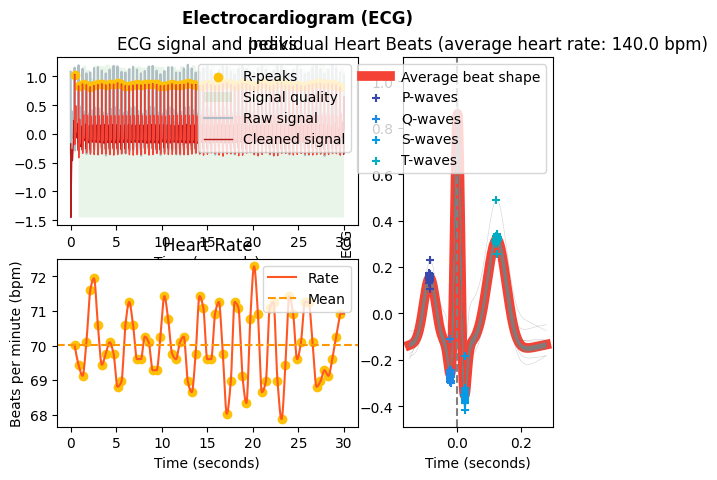

In [5]:
#ECG波形を可視化
ecg_simulated=nk.ecg_simulate(duration=DURATION, sampling_rate=SAMPLING_RATE)
nk.ecg_plot(nk.ecg_process(ecg_simulated, sampling_rate=SAMPLING_RATE)[0])
plt.show()

In [9]:
#HRV解析
hrv=nk.hrv(ecg_signal['ECG_R_Peaks'], sampling_rate=SAMPLING_RATE)
print(hrv[['HRV_MeanNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']].to_string())

   HRV_MeanNN  HRV_RMSSD    HRV_LF    HRV_HF  HRV_LFHF
0  857.264706  12.780582  0.035272  0.064197  0.549433


/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


In [12]:
#本物のデータを使用する
!pip install wfdb
import wfdb

SAMPFROM=0
SAMPTO=30000

record=wfdb.rdrecord('mitdb/100', sampfrom=0, sampto=30000, pn_dir='mitdb')
ecg_real=record.p_signal[:,0]
fs=record.fs
print(f"Sampling frequency:{fs}Hz")
print(f"data length:{len(ecg_real)/fs:.1f}s")

Sampling frequency:360Hz
data length:83.3s


In [13]:
print(record.comments)  # データの説明文が入っている

['69 M 1085 1629 x1', 'Aldomet, Inderal']


/usr/local/lib/python3.12/dist-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


<function matplotlib.pyplot.show(close=None, block=None)>

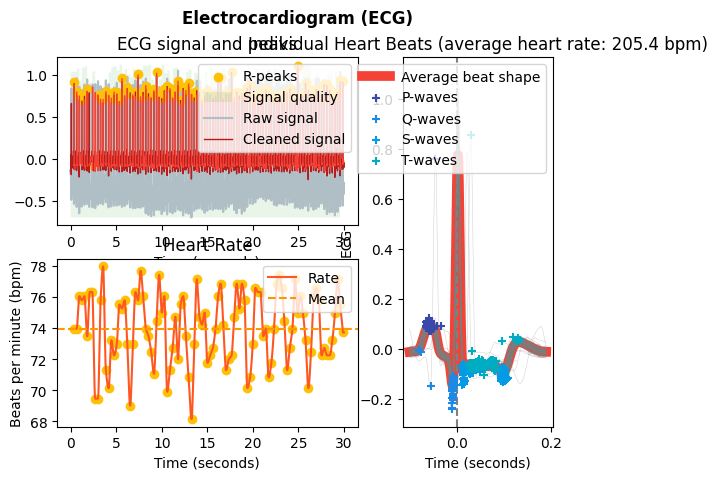

In [15]:
#グラフ化
ecg_processed,info_real=nk.ecg_process(ecg_real, sampling_rate=fs)
nk.ecg_plot(ecg_processed)
plt.show

In [16]:
hrv_real=nk.hrv(info_real['ECG_R_Peaks'], sampling_rate=fs)
print(hrv_real[['HRV_MeanNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']].to_string())

   HRV_MeanNN  HRV_RMSSD    HRV_LF    HRV_HF  HRV_LFHF
0  811.413641  27.972926  0.006084  0.035353  0.172101


/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
